# Assignment 4 - Training a DCGAN on the Fashion-MNIST Dataset

**Name:** Ashif Hussain

**Course:** BCA/Semester-V

**Reg. No.:** 2411021240056

**Subject:** Generative AI

**Date:** 12 September 2026

## Objective
To understand how a Deep Convolutional Generative Adversarial Network (DCGAN) is trained, and how the Generator and Discriminator improve over time through adversarial training on the Fashion-MNIST dataset.


In [5]:
# Step 1: Importing Library

# Import PyTorch main library
import torch

# Import neural network tools from PyTorch
import torch.nn as nn

# Import optimizer (helps model learn)
import torch.optim as optim

# Import tools to load and prepare dataset
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Import tools to show images
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# Step 2: Set the Basic Parameters

# Size of the random noise vector (input to generator)
noise_dim = 100

# Number of images processed together in one step
batch_size = 128

# Size of the images (Fashion-MNIST images are 28x28, we resize to 64x64)
image_size = 64

# Number of channels in image (1 = grayscale, since Fashion-MNIST is black & white)
channels = 1

# Number of times we go through the full dataset
num_epochs = 25

# Learning rate (how fast the model learns)
lr = 0.0002

# Device to run the code on (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
#Step 3: Load the Fashion-MNIST Data

# Steps to prepare each image before feeding to the model
transform = transforms.Compose([
    transforms.Resize(image_size),      # resize image to 64x64
    transforms.ToTensor(),              # convert image to tensor (numbers)
    transforms.Normalize((0.5,), (0.5,))  # scale pixel values from -1 to 1
])

# Download and load the Fashion-MNIST training dataset
dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Load data in small batches, shuffled randomly
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 166kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.08MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.8MB/s]


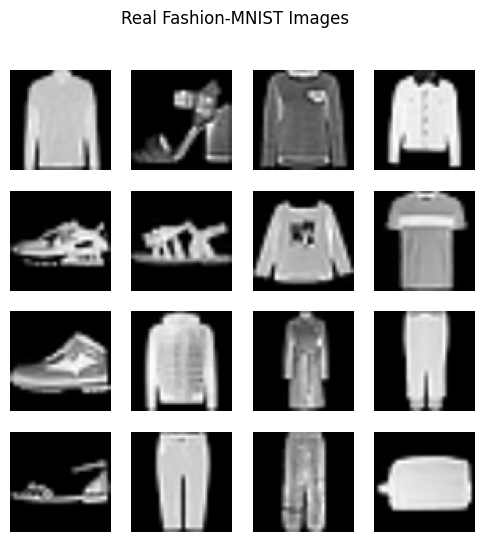

In [8]:
# Step 4: Show the Original Images

#What it means: Before training anything, let's look at some real Fashion-MNIST images. This helps us understand what the generator is trying to learn to copy.


# Get one batch of real images from the dataloader
real_batch = next(iter(dataloader))
images = real_batch[0]

# Set up a 4x4 grid to show 16 images
fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    # Convert image from tensor back to normal picture (undo normalization)
    img = images[i][0] * 0.5 + 0.5
    ax.imshow(img, cmap="gray")   # show as grayscale image
    ax.axis("off")                # hide the axis lines/numbers

plt.suptitle("Real Fashion-MNIST Images")
plt.show()

In [9]:
# Step 5: Building the Generator (Basic Idea)

# What it means: The Generator's job is to take random noise (random numbers) and turn it into a fake image.
#Think of it like starting with random static and slowly shaping it into a picture.
#We build this by increasing the size step by step — starting small and growing bigger, using layers that expand the noise into an image.

# Generator takes noise as input
# noise shape: (batch_size, noise_dim, 1, 1)
# It will pass through several layers
# Each layer will increase the size (like 4x4 -> 8x8 -> 16x16 -> 32x32 -> 64x64)
# The final output will be a 64x64 image

print("Generator plan: noise -> 4x4 -> 8x8 -> 16x16 -> 32x32 -> 64x64 image")

Generator plan: noise -> 4x4 -> 8x8 -> 16x16 -> 32x32 -> 64x64 image


In [10]:
#Step 6: Building the Generator Using Transposed Convolution Layers

# What it means: Now we build the real Generator. It uses "transposed convolution" layers —
#these are special layers that take a small input and expand it into a bigger image (opposite of normal convolution, which shrinks images).
#Each layer doubles the size, until we reach a 64x64 image. The last layer uses tanh so the output pixel values are between -1 and 1 (matching our normalized real images).

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input: noise (100, 1, 1) -> Output: (512, 4, 4)
            nn.ConvTranspose2d(noise_dim, 512, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(512),   # helps training be stable
            nn.ReLU(True),         # activation function

            # (512, 4, 4) -> (256, 8, 8)
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # (256, 8, 8) -> (128, 16, 16)
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # (128, 16, 16) -> (64, 32, 32)
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # (64, 32, 32) -> (1, 64, 64)  final image
            nn.ConvTranspose2d(64, channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()   # squashes output between -1 and 1
        )

    def forward(self, input):
        return self.main(input)

# Create the generator and move it to device (GPU/CPU)
generator = Generator().to(device)
print(generator)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)


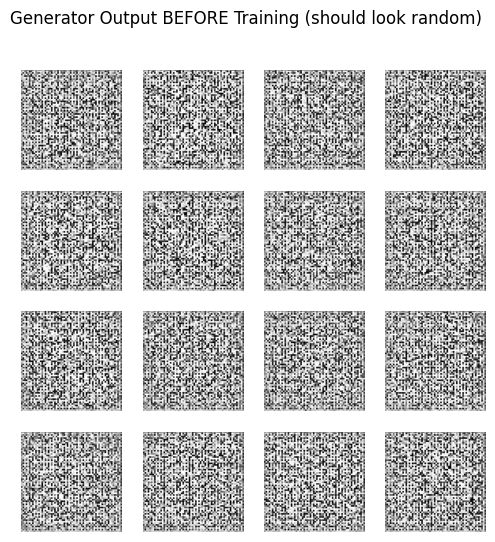

In [11]:
#Step 7: Testing Generator Before Training

#What it means: Before we train anything, let's check that the Generator works by feeding it pure random noise and seeing what it produces. Since it's untrained, the images will just look like random static/blobs — not real clothes yet. This just confirms our code runs correctly.

# Create random noise (16 samples, noise_dim, 1x1)
test_noise = torch.randn(16, noise_dim, 1, 1, device=device)

# Pass noise through the untrained generator
with torch.no_grad():          # no need to track gradients for a quick test
    test_images = generator(test_noise).cpu()

# Show the 16 generated images in a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    img = test_images[i][0] * 0.5 + 0.5   # undo normalization
    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.suptitle("Generator Output BEFORE Training (should look random)")
plt.show()

In [12]:
#Step 8: Building the Discriminator

#What it means: The Discriminator's job is the opposite of the Generator — it looks at an image and decides if it's "real" (from the actual dataset) or "fake" (made by the Generator). It uses normal convolution layers, which shrink the image step by step (64x64 → 32x32 → 16x16 → 8x8 → 4x4) until it becomes a single decision.


class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input: (1, 64, 64) -> (64, 32, 32)
            nn.Conv2d(channels, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),   # activation, allows small negative values

            # (64, 32, 32) -> (128, 16, 16)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # (128, 16, 16) -> (256, 8, 8)
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # (256, 8, 8) -> (512, 4, 4)
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # (512, 4, 4) -> (1, 1, 1)  final decision
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0, bias=False),
        )

    def forward(self, input):
        return self.main(input)

# Create the discriminator and move it to device
discriminator = Discriminator().to(device)
print(discriminator)

Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
  )
)


In [13]:
#Step 9: Go for the Sigmoid Function

#What it means: The Discriminator's last layer gives out a raw number (can be any value). We need this to be a probability between 0 and 1 — meaning "how sure it is the image is real." The sigmoid function squashes any number into the range 0 to 1.

# We add sigmoid AFTER the discriminator's raw output
# This turns the raw score into a probability (0 = fake, 1 = real)

sigmoid = nn.Sigmoid()

# Quick test: pass the discriminator's output through sigmoid
test_output = discriminator(test_images.to(device))
test_prob = sigmoid(test_output)
print("Sample discriminator probabilities (untrained):")
print(test_prob.view(-1)[:5])

Sample discriminator probabilities (untrained):
tensor([0.5761, 0.4778, 0.5313, 0.5418, 0.4578], device='cuda:0',
       grad_fn=<SliceBackward0>)


In [14]:
#Step 10: Defining the Loss Function and Optimizer

#What it means: We need a way to measure "how wrong" the model is (loss function), and a way to update the model to do better (optimizer). Following your labeling: fake images = label 1, real images = label 0. The loss function used is Binary Cross Entropy (BCE), which works well with probabilities from sigmoid.

# Loss function: measures how far predictions are from the true label
criterion = nn.BCELoss()

# Labels: fake = 1, real = 0 (as per your convention)
real_label = 0
fake_label = 1

# Optimizer for Discriminator (updates its weights to learn better)
optimizerD = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

# Optimizer for Generator (updates its weights to learn better)
optimizerG = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))

In [15]:
#Step 11: Training the Discriminator and Generator (Tracking Loss)

#What it means: Training happens in two parts, done one after another, for every batch of images:

#Train Discriminator — show it real images (label 0) and fake images (label 1), and let it learn to tell them apart.
#Train Generator — show its fake images to the Discriminator, and try to fool it into giving label 0 (real) instead of 1 (fake). This pushes the Generator to make better images.

#We also save the loss numbers so we can plot them later.


# Lists to store loss values for plotting later
G_losses = []
D_losses = []

def train_one_epoch(dataloader):
    for i, data in enumerate(dataloader):

        ############################
        # (1) Train Discriminator
        ############################
        discriminator.zero_grad()

        # --- Train with real images ---
        real_images = data[0].to(device)
        b_size = real_images.size(0)
        labels = torch.full((b_size,), real_label, dtype=torch.float, device=device)

        output = discriminator(real_images).view(-1)
        output = sigmoid(output)
        lossD_real = criterion(output, labels)
        lossD_real.backward()

        # --- Train with fake images ---
        noise = torch.randn(b_size, noise_dim, 1, 1, device=device)
        fake_images = generator(noise)
        labels.fill_(fake_label)

        output = discriminator(fake_images.detach()).view(-1)   # detach so generator isn't updated here
        output = sigmoid(output)
        lossD_fake = criterion(output, labels)
        lossD_fake.backward()

        # Total discriminator loss
        lossD = lossD_real + lossD_fake
        optimizerD.step()

        ############################
        # (2) Train Generator
        ############################
        generator.zero_grad()

        # Generator wants discriminator to think fake images are REAL (label 0)
        labels.fill_(real_label)
        output = discriminator(fake_images).view(-1)
        output = sigmoid(output)
        lossG = criterion(output, labels)
        lossG.backward()
        optimizerG.step()

        # Save losses
        G_losses.append(lossG.item())
        D_losses.append(lossD.item())

    return lossD.item(), lossG.item()

Epoch [1/25]  Loss D: 0.9278  Loss G: 0.9973
Epoch [2/25]  Loss D: 1.1312  Loss G: 0.9848
Epoch [3/25]  Loss D: 1.1857  Loss G: 0.2793
Epoch [4/25]  Loss D: 0.3028  Loss G: 2.8793
Epoch [5/25]  Loss D: 0.3686  Loss G: 6.2080


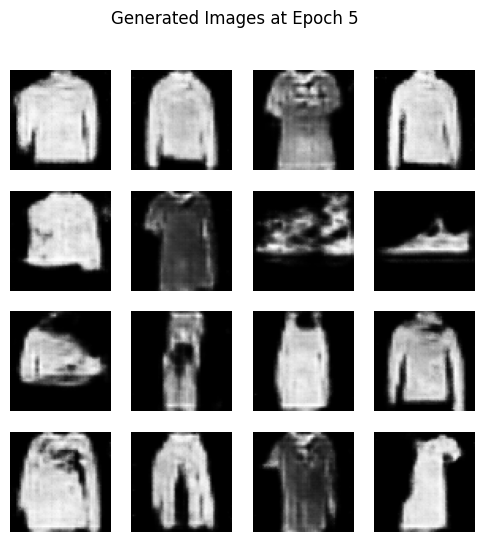

Epoch [6/25]  Loss D: 0.4491  Loss G: 0.9316
Epoch [7/25]  Loss D: 0.2196  Loss G: 3.6993
Epoch [8/25]  Loss D: 0.0400  Loss G: 4.0729
Epoch [9/25]  Loss D: 0.0603  Loss G: 4.1285
Epoch [10/25]  Loss D: 0.0769  Loss G: 4.9341


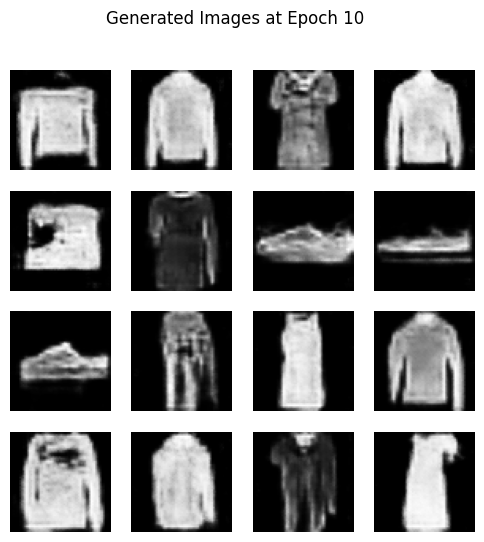

Epoch [11/25]  Loss D: 0.0465  Loss G: 4.4598
Epoch [12/25]  Loss D: 0.0120  Loss G: 5.6945
Epoch [13/25]  Loss D: 0.6072  Loss G: 1.7285
Epoch [14/25]  Loss D: 0.0515  Loss G: 4.9756
Epoch [15/25]  Loss D: 0.0617  Loss G: 4.7618


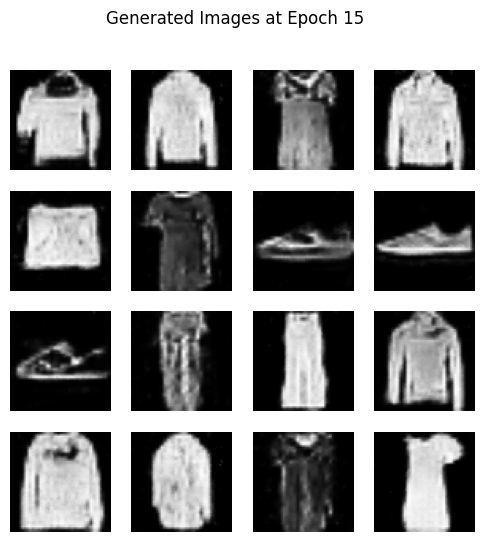

Epoch [16/25]  Loss D: 0.1278  Loss G: 4.1806
Epoch [17/25]  Loss D: 0.0899  Loss G: 3.5996
Epoch [18/25]  Loss D: 0.0494  Loss G: 4.6333
Epoch [19/25]  Loss D: 0.0148  Loss G: 5.8459
Epoch [20/25]  Loss D: 1.1857  Loss G: 2.5350


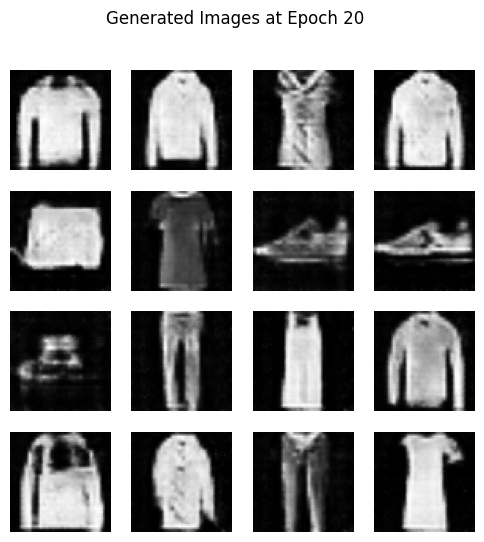

Epoch [21/25]  Loss D: 0.0539  Loss G: 5.1435
Epoch [22/25]  Loss D: 0.6397  Loss G: 1.9090
Epoch [23/25]  Loss D: 0.0436  Loss G: 4.0911
Epoch [24/25]  Loss D: 2.9406  Loss G: 87.6898
Epoch [25/25]  Loss D: 0.0242  Loss G: 5.2852


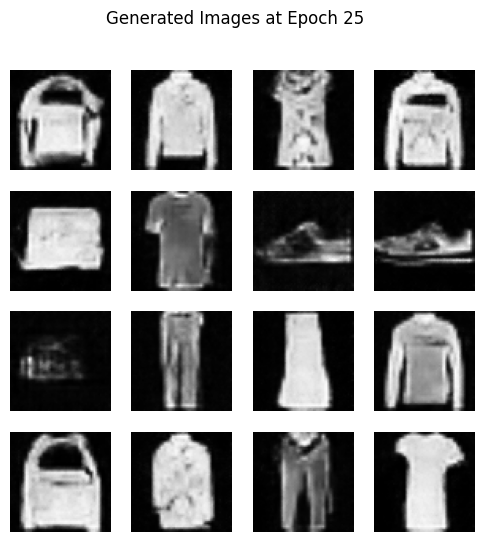

In [16]:
# Step 12: Train the Model for 25 Epochs (Save 4x4 Image Every 5 Epochs)

# What it means: Now we actually run the training loop. We go through the whole dataset 25 times (epochs). Every 5 epochs, we save a 4x4 grid of generated images, so later we can compare how the Generator improves over time.

# Fixed noise so we can compare the SAME noise across different epochs
fixed_noise = torch.randn(16, noise_dim, 1, 1, device=device)

# List to store image grids at different epochs
saved_grids = {}

def save_image_grid(epoch):
    with torch.no_grad():
        fake = generator(fixed_noise).cpu()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        img = fake[i][0] * 0.5 + 0.5   # undo normalization
        ax.imshow(img, cmap="gray")
        ax.axis("off")
    plt.suptitle(f"Generated Images at Epoch {epoch}")
    plt.savefig(f"epoch_{epoch}.png")   # save image file
    plt.show()

# Main training loop
for epoch in range(1, num_epochs + 1):
    lossD, lossG = train_one_epoch(dataloader)
    print(f"Epoch [{epoch}/{num_epochs}]  Loss D: {lossD:.4f}  Loss G: {lossG:.4f}")

    # Save image grid every 5 epochs
    if epoch % 5 == 0:
        save_image_grid(epoch)

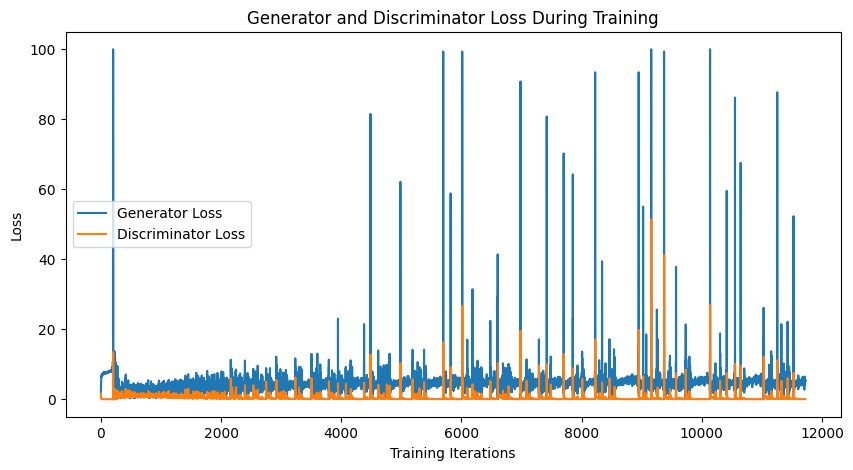

In [17]:
# Step 13: Plot Generator and Discriminator Loss

# What it means: Now that training is finished, we plot the loss values we saved during training. This helps us see how well the Generator and Discriminator competed against each other over time — whether the losses became stable, or jumped around a lot (instability).

plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.xlabel("Training Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

Final Step: Written Observations (Answer the 4 Questions)

# Observations on DCGAN Training

**1. How do images change from epoch 5 to 25?**

Even by epoch 5, rough clothing shapes (sweaters, shirts) were already visible. From epoch 10 to 25, the shapes become slightly cleaner and more consistent, but overall there isn't a huge jump in quality — epoch 25 images look fairly similar to epoch 15-20 images, just marginally sharper in some cases.

**2. Do you observe instability in training?**

Yes, clearly. Looking at the loss graph, the Discriminator loss (orange) stays close to 0 most of the time, while the Generator loss (blue) spikes very high repeatedly (sometimes above 60-100, like at epoch 24 where Loss G jumped to 87.68). This shows the Discriminator became too strong/confident at many points, making it hard for the Generator to learn steadily — a sign of unstable training.

**3. At which epoch do recognizable clothing shapes become visible?**

Recognizable shapes (sweaters, t-shirts, shoes) are already visible by epoch 5, and become a bit more defined by epoch 10-15.

**4. Does image quality keep improving throughout training?**

No — quality improves early on (epoch 5 to 15) but then plateaus. Epoch 20 and epoch 25 images look very similar to each other, and many generated images repeat similar sweater/shirt-like shapes across different noise inputs — suggesting partial mode collapse (the Generator settling into a few "safe" shapes rather than producing full variety).